# Benchmarking – Baseline Simulation Studies:
## 1) Imports and Set-Up:

### 1.1) Imports & Seed-Setting:

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "notebooks" / "benchmarking_code"))

In [2]:
import multiprocessing
import os, random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

We set random seeds:

In [3]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

In [4]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass

    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 3

    return max(1, n_cores - 1)


N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [5]:
PROVIDE_TEX_OUTPUT = True

In [6]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


### 1.2) Helper-Functions:

In [7]:
from benchmarking_runners import benchmark_cluster_metrics, benchmark_scaling
from benchmarking_plotting import (
    plot_examples,
    plot_ari_over_difficulty,
    plot_baseline_vs_metric_ari_grid,
    plot_paper_figure,
)
from benchmarking_reporting import summarize_regime_tables

---

## 2) Default Benchmarks:

### 2.1) Gaussians Mixtures:

In [ ]:
settings_by_k_gaussians = {
    3: {
        "easy": {"cluster_scale": [4.0] * 3, "cluster_size_dirichlet_alpha": 0.9},
        "medium": {"cluster_scale": [4.5] * 3, "cluster_size_dirichlet_alpha": 0.5},
        "hard": {"cluster_scale": [4.6] * 3, "cluster_size_dirichlet_alpha": 0.1},
    },
    4: {
        "easy": {"cluster_scale": [4.0] * 4, "cluster_size_dirichlet_alpha": 0.9},
        "medium": {"cluster_scale": [4.3] * 4, "cluster_size_dirichlet_alpha": 0.3},
        "hard": {"cluster_scale": [4.3] * 4, "cluster_size_dirichlet_alpha": 0.1},
    }
}

other_settings_gaussians = {"n_total": 500, "p": 50}

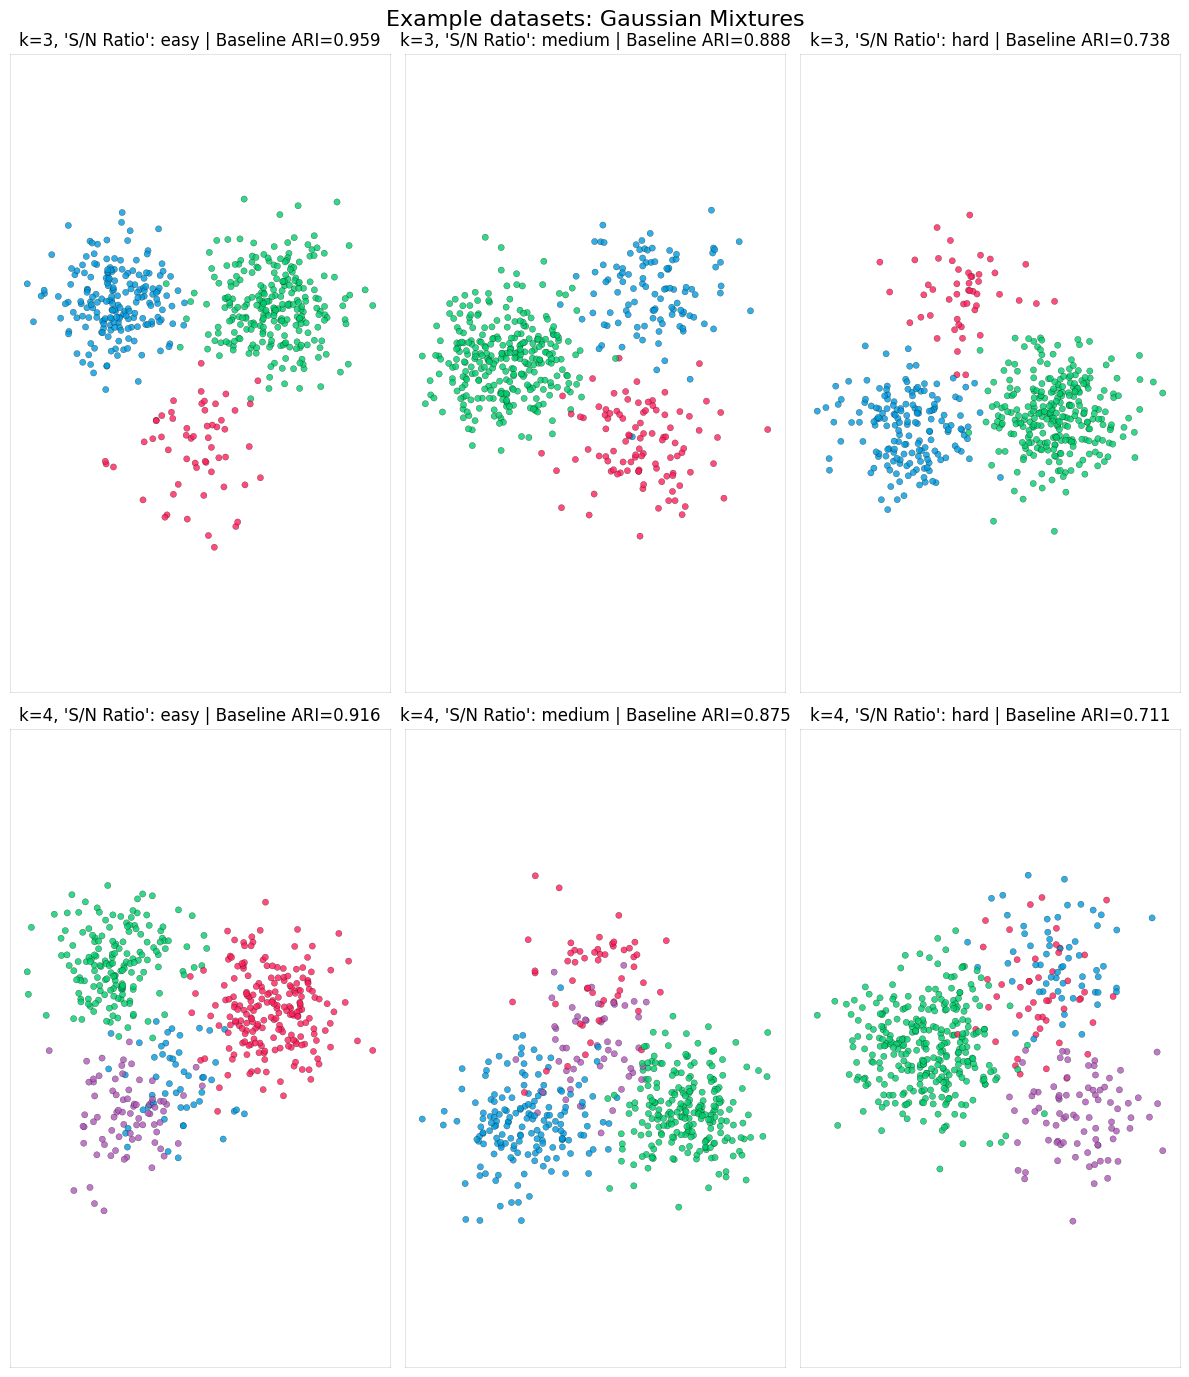

In [9]:
plot_examples(
    settings_by_k=settings_by_k_gaussians,
    other_settings=other_settings_gaussians,
    estimator_type="kmeans",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [ ]:
results_path = "../results/results_gaussian.csv"

if not os.path.exists(results_path):
    results_gaussian = benchmark_cluster_metrics(
        settings_by_k_gaussians,
        other_settings_gaussians,
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_gaussian.to_csv(results_path, index=False)

else:
    results_gaussian = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    settings_by_k_gaussians,
    other_settings_gaussians,
    get_snapshot=True,
    snapshot_df=results_gaussian,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED + 1,
)

_ = plot_ari_over_difficulty(results_gaussian, show_band_for=())

_ = plot_baseline_vs_metric_ari_grid(results_gaussian)

In [ ]:
tables_gaussian = summarize_regime_tables(results_gaussian, true_ks=(3, 4))
display(tables_gaussian["ari_df"])
display(tables_gaussian["k_recovery_df"])

In [ ]:
if PROVIDE_TEX_OUTPUT:
    print(tables_gaussian["ari_tex"])
    print(tables_gaussian["k_recovery_tex"])

---

### 2.2) t-Distributed Mixtures:

In [ ]:
settings_by_k_t_dist = {
    3: {
        "easy": {
            "cluster_scale": [4.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "t_df": 5,
        },
        "medium": {
            "cluster_scale": [4.0, 1.2, 1.0],
            "cluster_size_dirichlet_alpha": 0.3,
            "t_df": 4,
        },
        "hard": {
            "cluster_scale": [4.0, 1.3, 1.0],
            "cluster_size_dirichlet_alpha": 0.3,
            "t_df": 3,
        },
    },
    4: {
        "easy": {
            "cluster_scale": [3.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "t_df": 5,
        },
        "medium": {
            "cluster_scale": [4.0, 2.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.2,
            "t_df": 4,
        },
        "hard": {
            "cluster_scale": [4.0, 2.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.1,
            "t_df": 3,
        },
    }
}

other_settings_t_dist = {"n_total": 500, "p": 50, "distribution": "t"}

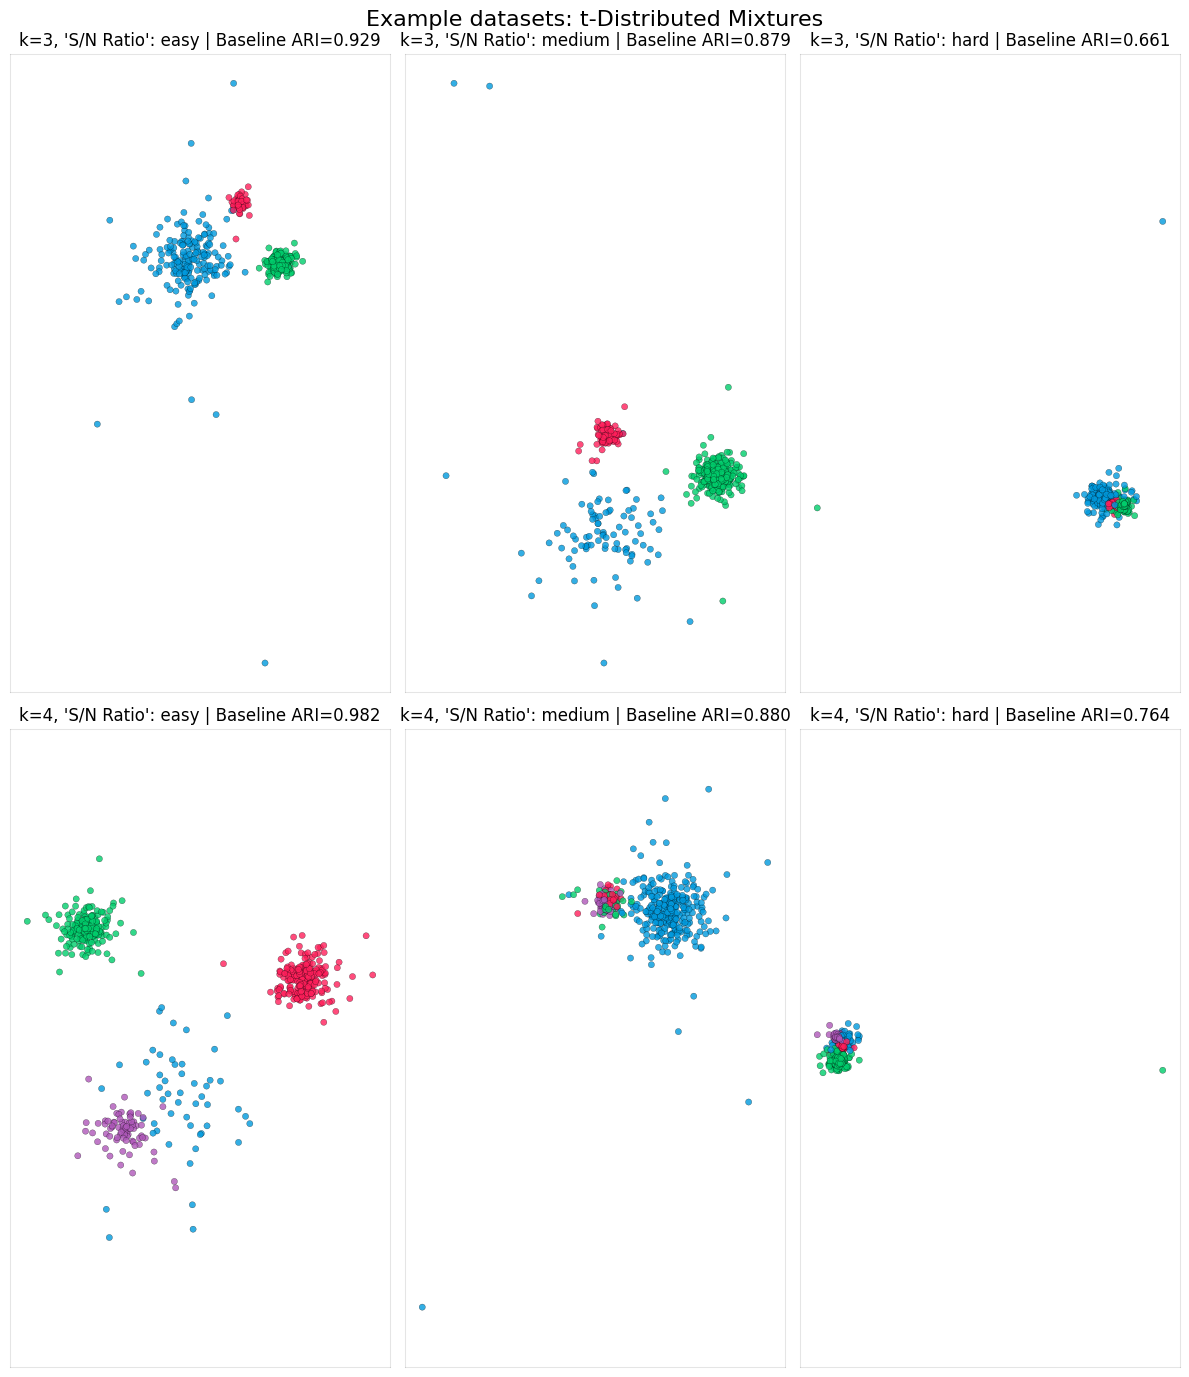

In [11]:
plot_examples(
    settings_by_k=settings_by_k_t_dist,
    other_settings=other_settings_t_dist,
    estimator_type="agglomerative",
    example_title="t-Distributed Mixtures",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [ ]:
results_path = "../results/results_t_dist.csv"

if not os.path.exists(results_path):
    results_t_dist = benchmark_cluster_metrics(
        settings_by_k_t_dist,
        other_settings_t_dist,
        estimator="agglomerative",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_t_dist.to_csv(results_path, index=False)

else:
    results_t_dist = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    settings_by_k_t_dist,
    other_settings_t_dist,
    estimator="agglomerative",
    get_snapshot=True,
    snapshot_df=results_t_dist,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

_ = plot_ari_over_difficulty(results_t_dist, show_band_for=())

_ = plot_baseline_vs_metric_ari_grid(results_t_dist)

In [ ]:
tables_t_dist = summarize_regime_tables(results_t_dist, true_ks=(3, 4))
display(tables_t_dist["ari_df"])
display(tables_t_dist["k_recovery_df"])

In [ ]:
if PROVIDE_TEX_OUTPUT:
    print(tables_t_dist["ari_tex"])
    print(tables_t_dist["k_recovery_tex"])

---

### 2.3) t-Distributed Mixtures with Nuisance Dimensions:

In [ ]:
settings_by_k_t_dist_noise = {
    3: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "t_df": 5,
            "corr_strength": 0.1,
            "noise_dims": 512,
        },
        "medium": {
            "cluster_scale": [1.3, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.1,
            "t_df": 4,
            "corr_strength": 0.4,
            "noise_dims": 1536,
        },
        "hard": {
            "cluster_scale": [1.3, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.1,
            "t_df": 3,
            "corr_strength": 0.5,
            "noise_dims": 2048,
        },
    },
    4: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.9,
            "t_df": 5,
            "corr_strength": 0.1,
            "noise_dims": 512,
        },
        "medium": {
            "cluster_scale": [1.1, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.3,
            "t_df": 4,
            "corr_strength": 0.3,
            "noise_dims": 1280,
        },
        "hard": {
            "cluster_scale": [1.1, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.2,
            "t_df": 3,
            "corr_strength": 0.5,
            "noise_dims": 1536,
        },
    }
}

other_settings_t_dist_noise = {
    "n_total": 500,
    "p": 50,
    "corr_type": "ar1",
    "distribution": "t",
}

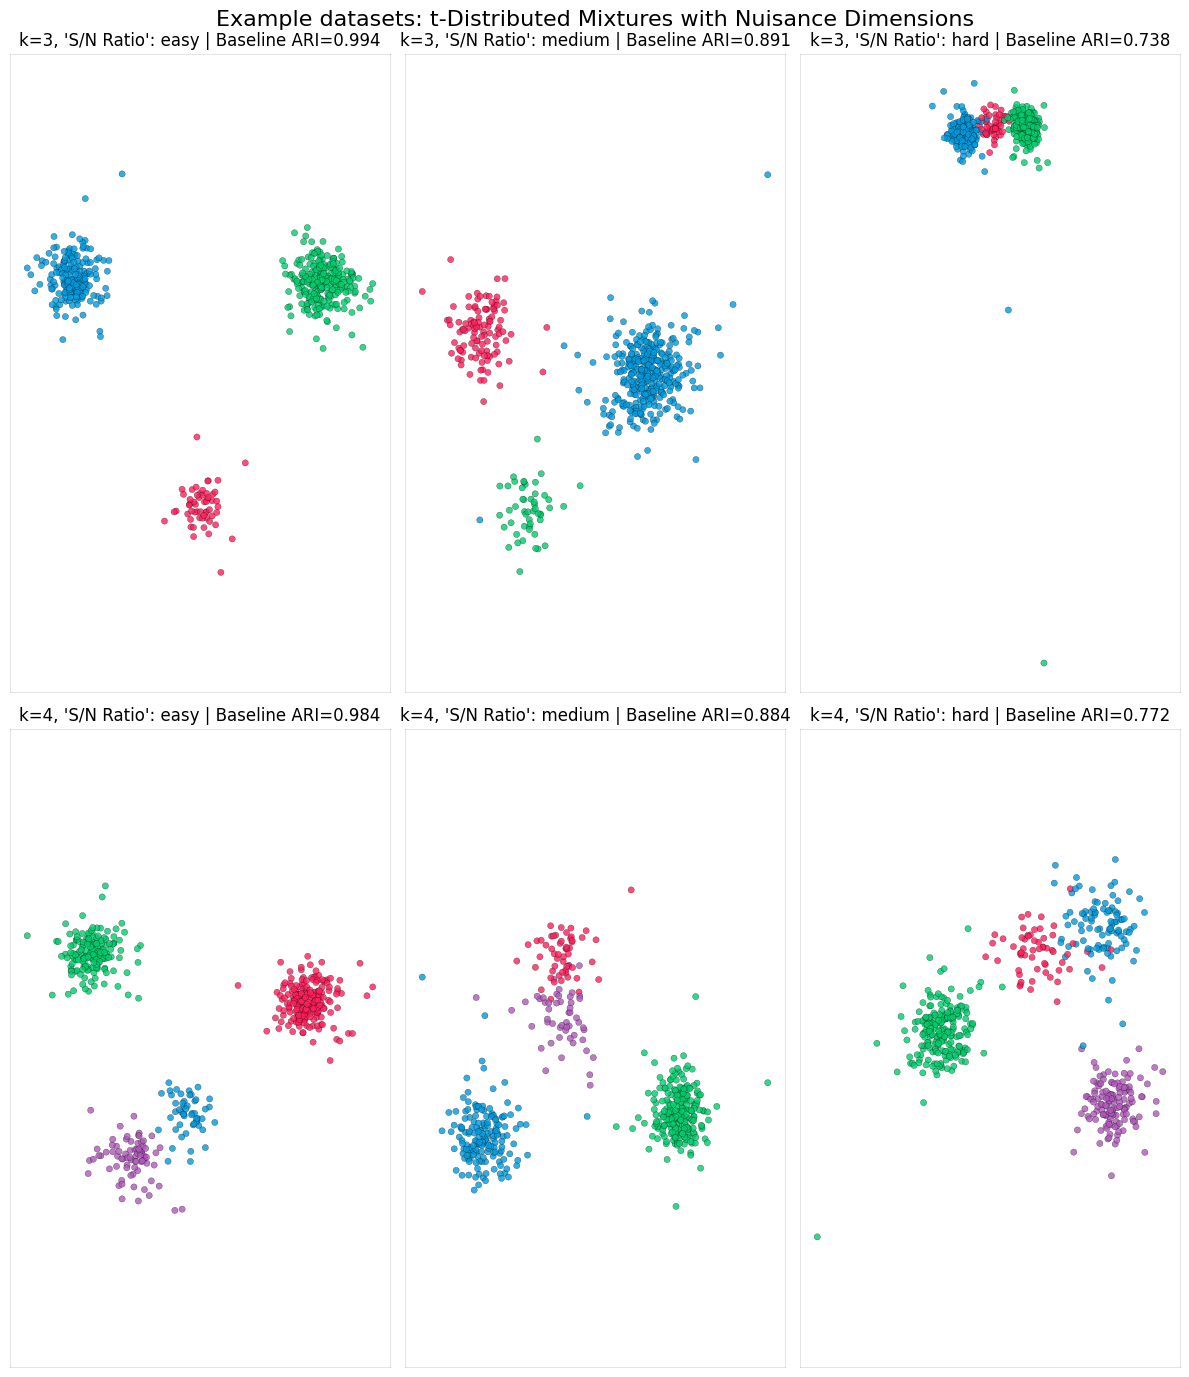

In [13]:
plot_examples(
    settings_by_k=settings_by_k_t_dist_noise,
    other_settings=other_settings_t_dist_noise,
    estimator_type="agglomerative",
    example_title="t-Distributed Mixtures with Nuisance Dimensions",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [ ]:
results_path = "../results/results_t_dist_noise.csv"

if not os.path.exists(results_path):
    results_t_dist_noise = benchmark_cluster_metrics(
        settings_by_k_t_dist_noise,
        other_settings_t_dist_noise,
        estimator="agglomerative",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_t_dist_noise.to_csv(results_path, index=False)

else:
    results_t_dist_noise = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    settings_by_k_t_dist_noise,
    other_settings_t_dist_noise,
    estimator="agglomerative",
    get_snapshot=True,
    snapshot_df=results_t_dist_noise,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED + 2,
)

_ = plot_ari_over_difficulty(results_t_dist_noise, show_band_for=())

_ = plot_baseline_vs_metric_ari_grid(results_t_dist_noise)

In [ ]:
tables_t_dist_noise = summarize_regime_tables(results_t_dist_noise, true_ks=(3, 4))
display(tables_t_dist_noise["ari_df"])
display(tables_t_dist_noise["k_recovery_df"])

In [ ]:
if PROVIDE_TEX_OUTPUT:
    print(tables_t_dist_noise["ari_tex"])
    print(tables_t_dist_noise["k_recovery_tex"])

---

### 2.4) RFF Embedded Circles:

In [16]:
settings_by_k_circles = {
    3: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 0.5],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 12.0,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 12.0,
        },
    },
    4: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 1.0, 0.5],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 10.0,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 8.0,
        },
    },
}

other_settings_circles = {
    "n_total": 500,
    "p": 50,
    "corr_type": "ar1",
    "distribution": "circles",
    "nonlinear": True,
    "embed_dim": 64,
}

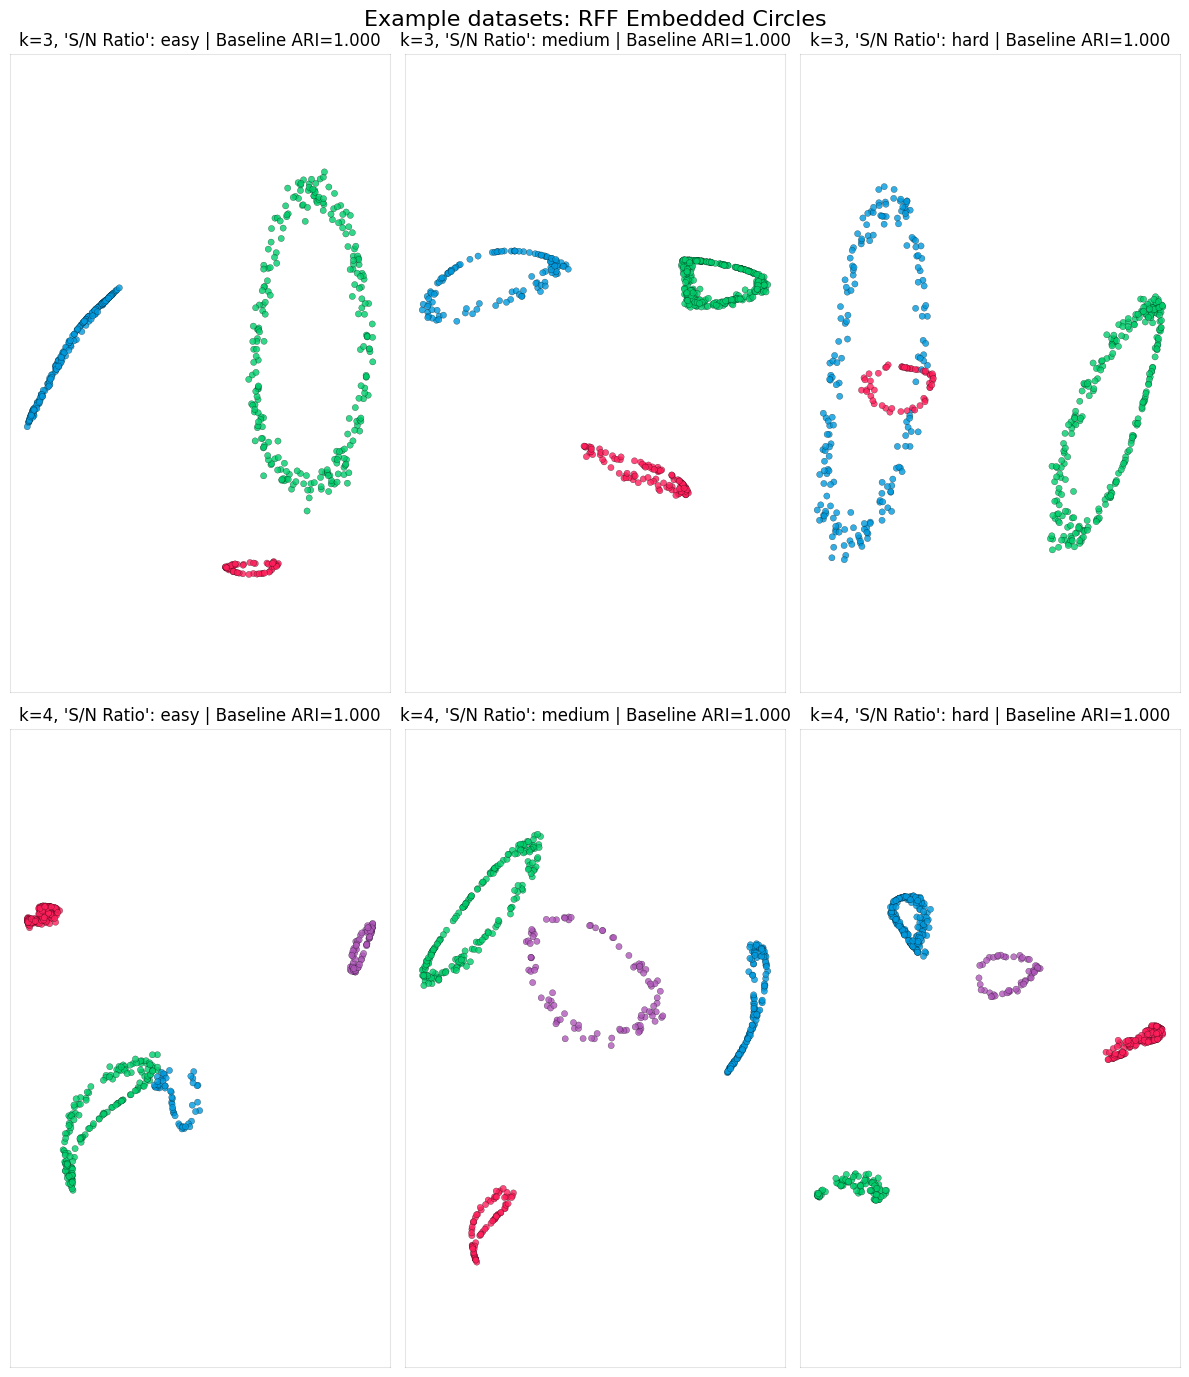

In [17]:
plot_examples(
    settings_by_k=settings_by_k_circles,
    other_settings=other_settings_circles,
    estimator_type="spectral",
    example_title="RFF Embedded Circles",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [ ]:
results_path = "../results/results_circles.csv"

if not os.path.exists(results_path):
    results_circles = benchmark_cluster_metrics(
        settings_by_k_circles,
        other_settings_circles,
        estimator="spectral",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_circles.to_csv(results_path, index=False)

else:
    results_circles = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    settings_by_k_circles,
    other_settings_circles,
    estimator="spectral",
    get_snapshot=True,
    snapshot_df=results_circles,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

_ = plot_ari_over_difficulty(results_circles, show_band_for=())

_ = plot_baseline_vs_metric_ari_grid(results_circles)

In [ ]:
tables_circles = summarize_regime_tables(results_circles, true_ks=(3, 4))
display(tables_circles["ari_df"])
display(tables_circles["k_recovery_df"])

In [ ]:
if PROVIDE_TEX_OUTPUT:
    print(tables_circles["ari_tex"])
    print(tables_circles["k_recovery_tex"])

---

### 2.5) RFF Embedded Moons:

In [18]:
settings_by_k_moons = {
    3: {
        "easy": {
            "cluster_scale": [1.0, 0.5, 0.5],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 12.0,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 12.0,
        },
    },
    4: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 0.5, 0.5],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 10.0,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 8.0,
        },
    },
}

other_settings_moons = {
    "n_total": 500,
    "p": 50,
    "corr_type": "ar1",
    "distribution": "moons",
    "nonlinear": True,
    "embed_dim": 64,
}

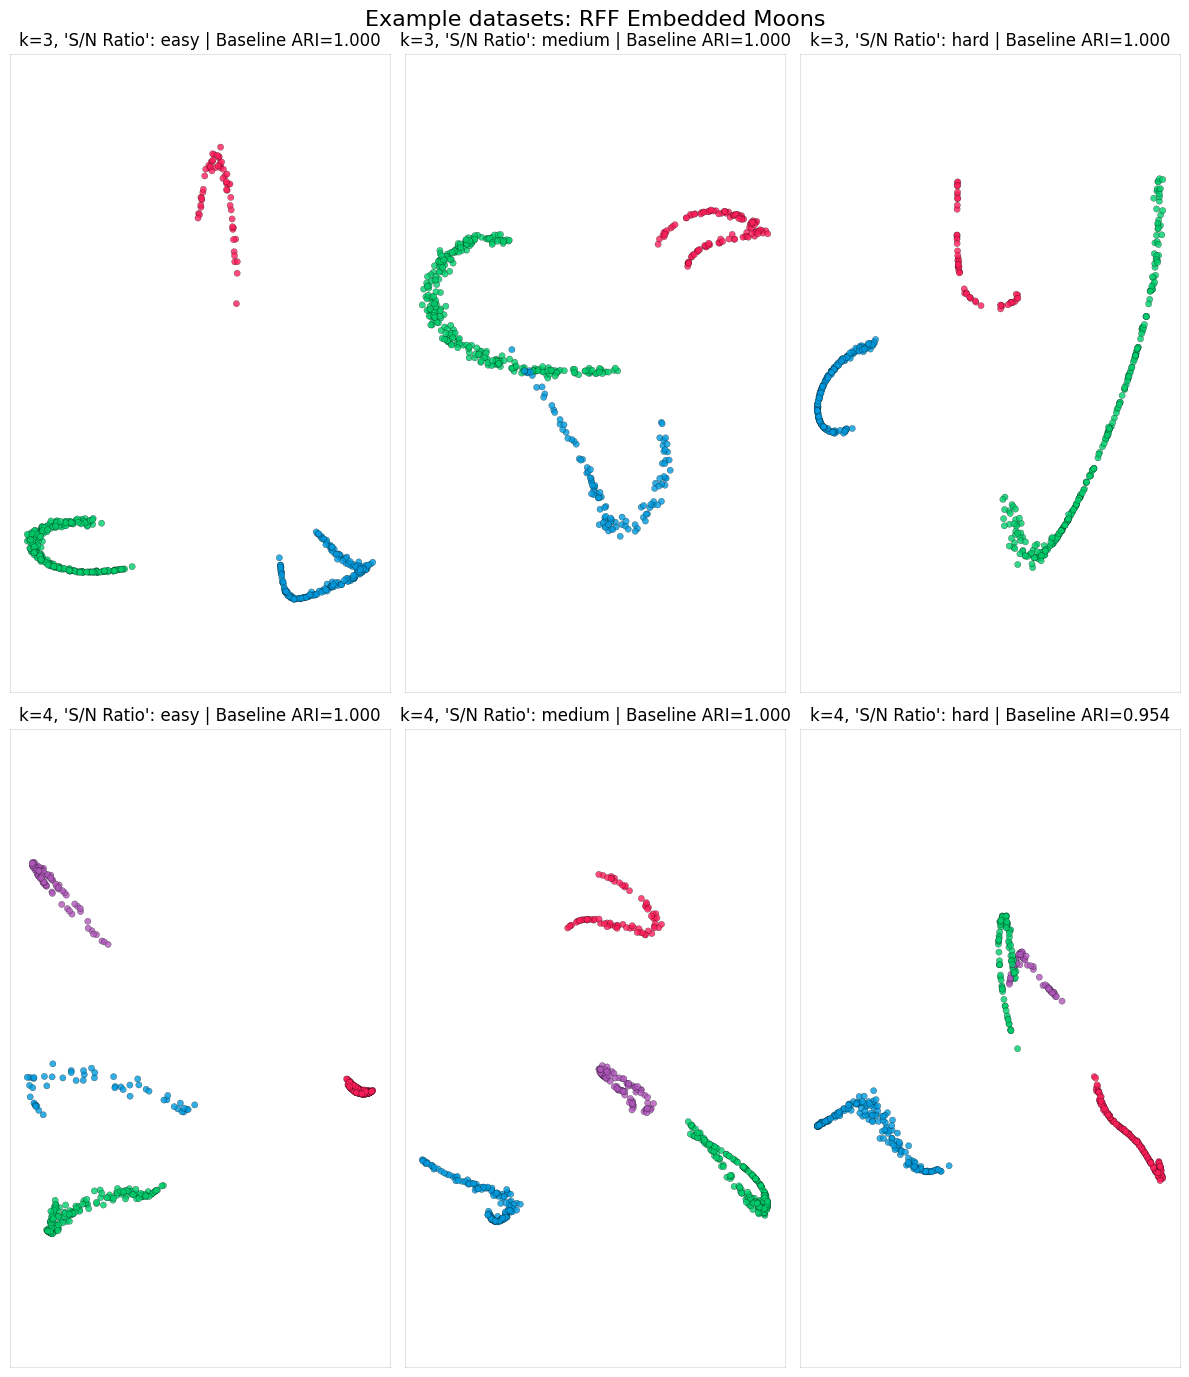

In [19]:
plot_examples(
    settings_by_k=settings_by_k_moons,
    other_settings=other_settings_moons,
    estimator_type="spectral",
    example_title="RFF Embedded Moons",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [ ]:
results_path = "../results/results_moons.csv"

if not os.path.exists(results_path):
    results_moons = benchmark_cluster_metrics(
        settings_by_k_moons,
        other_settings_moons,
        estimator="spectral",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_moons.to_csv(results_path, index=False)

else:
    results_moons = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    settings_by_k_moons,
    other_settings_moons,
    estimator="spectral",
    get_snapshot=True,
    snapshot_df=results_moons,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

_ = plot_ari_over_difficulty(results_moons, show_band_for=())

_ = plot_baseline_vs_metric_ari_grid(results_moons)

In [ ]:
tables_moons = summarize_regime_tables(results_moons, true_ks=(3, 4))
display(tables_moons["ari_df"])
display(tables_moons["k_recovery_df"])

In [ ]:
if PROVIDE_TEX_OUTPUT:
    print(tables_moons["ari_tex"])
    print(tables_moons["k_recovery_tex"])

---

### 2.6) RFF Embedded Swiss Rolls:

In [20]:
settings_by_k_swiss_rolls = {
    3: {
        "easy": {
            "cluster_scale": [1.0, 0.5, 0.5],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 12.0,
        },
        "hard": {
            "cluster_scale": [1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 12.0,
        },
    },
    4: {
        "easy": {
            "cluster_scale": [1.0, 1.0, 0.5, 0.5],
            "cluster_size_dirichlet_alpha": 0.9,
            "corr_strength": 0.1,
            "embed_param": 12.0,
        },
        "medium": {
            "cluster_scale": [1.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.7,
            "corr_strength": 0.3,
            "embed_param": 8.0,
        },
        "hard": {
            "cluster_scale": [2.0, 1.0, 1.0, 1.0],
            "cluster_size_dirichlet_alpha": 0.5,
            "corr_strength": 0.5,
            "embed_param": 8.0,
        },
    },
}

other_settings_swiss_rolls = {
    "n_total": 500,
    "p": 50,
    "corr_type": "ar1",
    "distribution": "swiss_roll",
    "nonlinear": True,
    "embed_dim": 64,
}

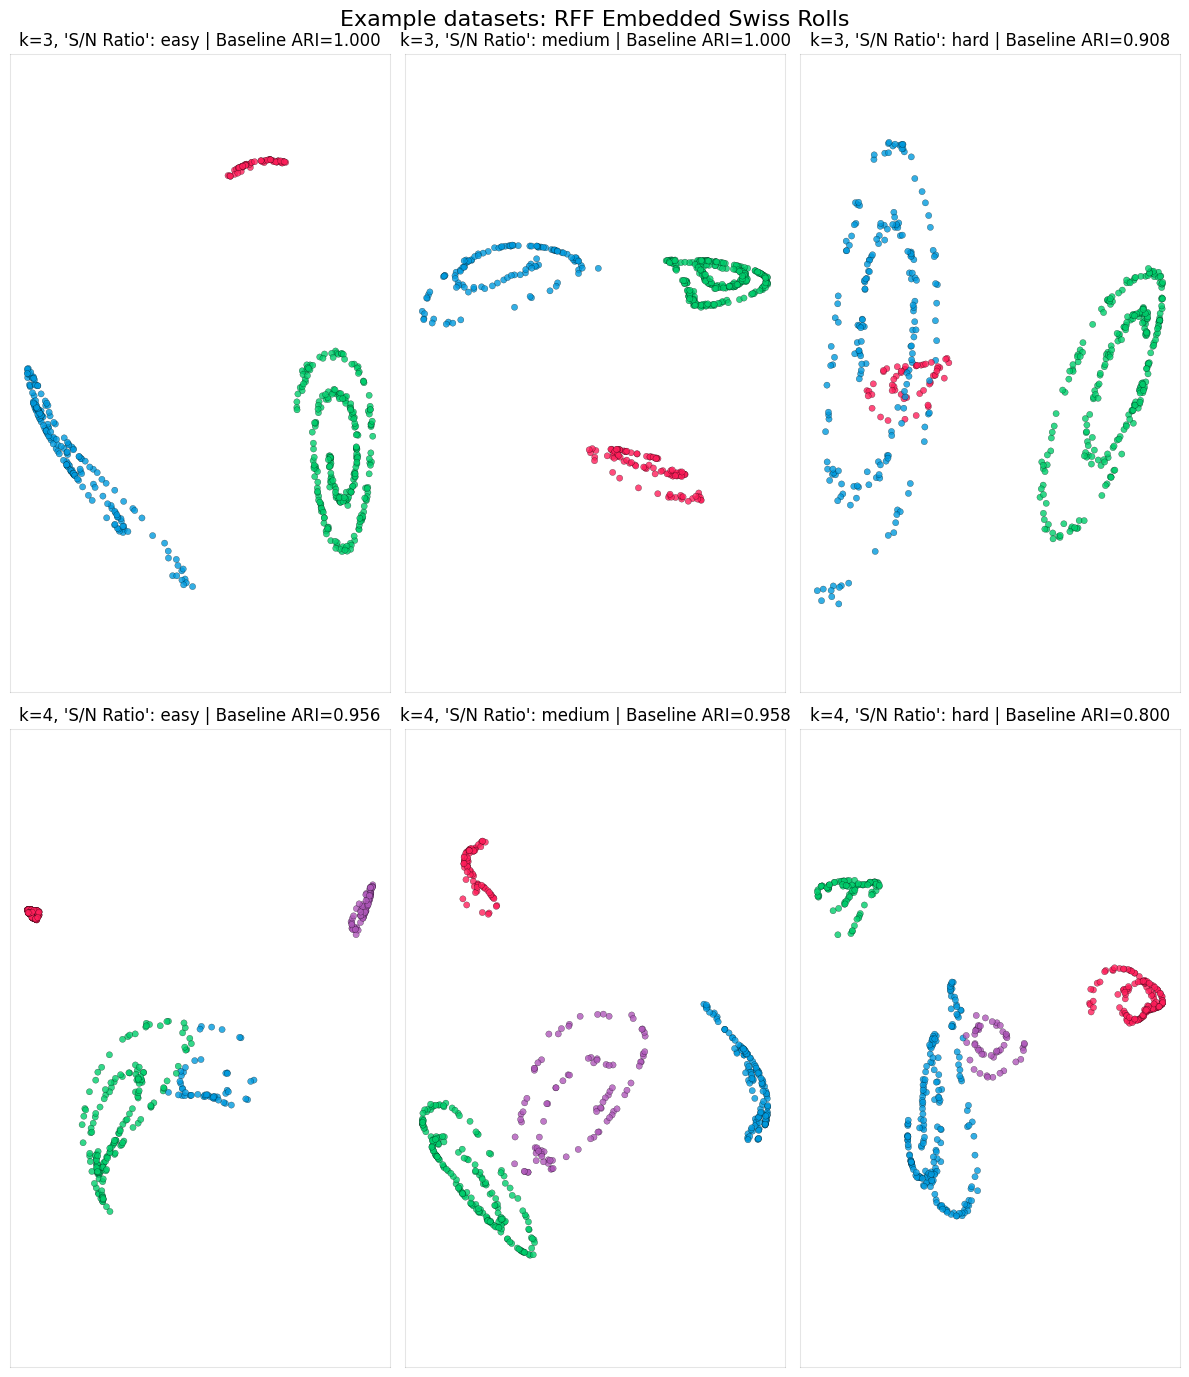

In [21]:
plot_examples(
    settings_by_k=settings_by_k_swiss_rolls,
    other_settings=other_settings_swiss_rolls,
    estimator_type="spectral",
    example_title="RFF Embedded Swiss Rolls",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [ ]:
results_path = "../results/results_swiss_rolls.csv"

if not os.path.exists(results_path):
    results_swiss_rolls = benchmark_cluster_metrics(
        settings_by_k_swiss_rolls,
        other_settings_swiss_rolls,
        estimator="spectral",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_swiss_rolls.to_csv(results_path, index=False)

else:
    results_swiss_rolls = pd.read_csv(results_path)

In [ ]:
_ = benchmark_cluster_metrics(
    settings_by_k_swiss_rolls,
    other_settings_swiss_rolls,
    estimator="spectral",
    get_snapshot=True,
    snapshot_df=results_swiss_rolls,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

_ = plot_ari_over_difficulty(results_swiss_rolls, show_band_for=())

_ = plot_baseline_vs_metric_ari_grid(results_swiss_rolls)

In [ ]:
tables_swiss_rolls = summarize_regime_tables(results_swiss_rolls, true_ks=(3, 4))
display(tables_swiss_rolls["ari_df"])
display(tables_swiss_rolls["k_recovery_df"])

In [ ]:
if PROVIDE_TEX_OUTPUT:
    print(tables_swiss_rolls["ari_tex"])
    print(tables_swiss_rolls["k_recovery_tex"])

---

## 3) Scalability Benchmarks:

### 3.1) Gaussians Mixtures:

#### 3.1.1) Dimensionality:

In [22]:
settings_by_k_gaussians_dimensionality = {
    3: {
        "start": {"cluster_scale": [2] * 3},
        "middle": {"cluster_scale": [4] * 3},
        "end": {"cluster_scale": [8.5] * 3},
    },
    4: {
        "start": {"cluster_scale": [1.75] * 4},
        "middle": {"cluster_scale": [4] * 4},
        "end": {"cluster_scale": [9] * 4},
    },
}

other_settings_gaussians_dimensionality = {
    "corr_type": "ar1",
    "corr_strength": 0.5,
    "cluster_size_dirichlet_alpha": 0.5,
}

In [ ]:
plot_examples(
    settings_by_k=settings_by_k_gaussians_dimensionality,
    other_settings=other_settings_gaussians_dimensionality,
    level_label="p",
    example_title="Gaussian Mixtures (Increasing Dimensionality)",
    sampler="scaling",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [ ]:
results_path = "../results/results_gaussian_dimensionality.csv"
runtimes_path = "../results/runtimes_gaussian_dimensionality.csv"

if not os.path.exists(results_path):
    results_gaussian_dimensionality, runtimes_gaussian_dimensionality = (
        benchmark_scaling(
            settings_by_k_gaussians_dimensionality,
            other_settings_gaussians_dimensionality,
            axis_name="p",
            n_jobs=N_JOBS,
            random_state=RANDOM_SEED,
        )
    )

    os.makedirs("../results/", exist_ok=True)
    results_gaussian_dimensionality.to_csv(results_path, index=False)
    runtimes_gaussian_dimensionality.to_csv(runtimes_path, index=False)

else:
    results_gaussian_dimensionality = pd.read_csv(results_path)
    runtimes_gaussian_dimensionality = pd.read_csv(runtimes_path)

In [ ]:
_ = plot_ari_over_difficulty(
    results_gaussian_dimensionality,
)

# _ = plot_baseline_vs_metric_ari_grid(results_gaussian_dimensionality)

#### 3.1.2) Number of Samples:

In [ ]:
settings_by_k_gaussians_samples = {
    3: {
        "start": {"cluster_scale": [3.7] * 3},
        "middle": {"cluster_scale": [4.2] * 3},
        "end": {"cluster_scale": [4.3] * 3},
    },
    4: {
        "start": {"cluster_scale": [3] * 4},
        "middle": {"cluster_scale": [4.3] * 4},
        "end": {"cluster_scale": [4.5] * 4},
    },
}

other_settings_gaussians_samples = {
    "corr_type": "ar1",
    "corr_strength": 0.5,
    "cluster_size_dirichlet_alpha": 0.5,
}

In [ ]:
plot_examples(
    settings_by_k=settings_by_k_gaussians_samples,
    other_settings=other_settings_gaussians_samples,
    level_label="n_total",
    example_title="Gaussian Mixtures (Increasing Number of Samples)",
    sampler="scaling",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [ ]:
results_path = "../results/results_gaussian_samples.csv"
runtimes_path = "../results/runtimes_gaussian_samples.csv"

if not os.path.exists(results_path):
    results_gaussian_samples, runtimes_gaussian_samples = benchmark_scaling(
        settings_by_k_gaussians_samples,
        other_settings_gaussians_samples,
        axis_name="n_total",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_gaussian_samples.to_csv(results_path, index=False)
    runtimes_gaussian_samples.to_csv(runtimes_path, index=False)

else:
    results_gaussian_samples = pd.read_csv(results_path)
    runtimes_gaussian_samples = pd.read_csv(runtimes_path)

In [ ]:
_ = plot_ari_over_difficulty(
    results_gaussian_samples,
)

# _ = plot_baseline_vs_metric_ari_grid(results_gaussian_samples)

---

### 3.2) RFF Embedded Moons:

#### 3.2.1) Dimensionality:

In [23]:
settings_by_k_moons_dimensionality = {
    3: {
        "start": {"cluster_scale": [1.0, 0.5, 0.5], "embed_param": 11.0},
        "middle": {"cluster_scale": [1.0, 0.9, 0.8], "embed_param": 6.5},
        "end": {"cluster_scale": [2.0, 1.0, 1.0], "embed_param": 6.0},
    },
    4: {
        "start": {"cluster_scale": [1.0, 0.5, 0.5, 0.25], "embed_param": 8.0},
        "middle": {"cluster_scale": [1.0, 1.0, 1.0, 1.0], "embed_param": 4.0},
        "end": {"cluster_scale": [1.0, 1.0, 1.0, 1.0], "embed_param": 4.0},
    },
}

other_settings_moons_dimensionality = {
    "corr_type": "ar1",
    "corr_strength": 0.5,
    "cluster_size_dirichlet_alpha": 0.5,
    "distribution": "moons",
    "nonlinear": True,
}

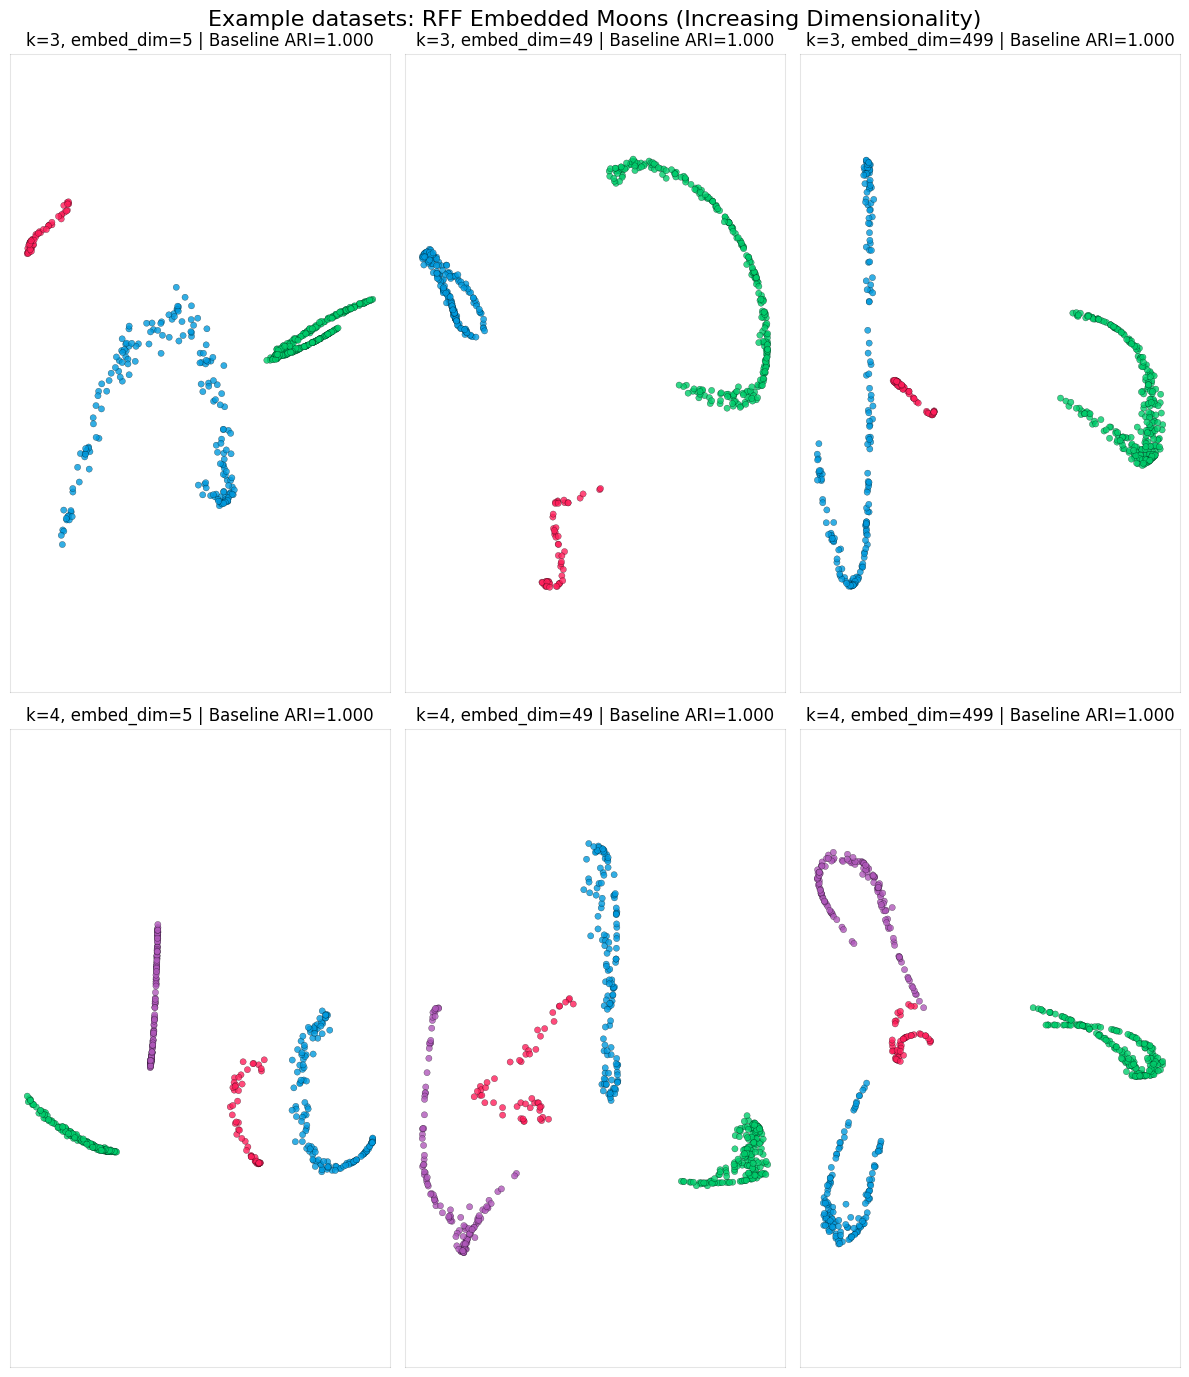

In [24]:
plot_examples(
    settings_by_k=settings_by_k_moons_dimensionality,
    other_settings=other_settings_moons_dimensionality,
    level_label="embed_dim",
    estimator_type="spectral",
    example_title="RFF Embedded Moons (Increasing Dimensionality)",
    sampler="scaling",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [ ]:
results_path = "../results/results_moons_dimensionality.csv"
runtimes_path = "../results/runtimes_moons_dimensionality.csv"

if not os.path.exists(results_path):
    results_moons_dimensionality, runtimes_moons_dimensionality = benchmark_scaling(
        settings_by_k_moons_dimensionality,
        other_settings_moons_dimensionality,
        axis_name="embed_dim",
        estimator="spectral",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_moons_dimensionality.to_csv(results_path, index=False)
    runtimes_moons_dimensionality.to_csv(runtimes_path, index=False)

else:
    results_moons_dimensionality = pd.read_csv(results_path)
    runtimes_moons_dimensionality = pd.read_csv(runtimes_path)

In [ ]:
_ = plot_ari_over_difficulty(
    results_moons_dimensionality,
)

# _ = plot_baseline_vs_metric_ari_grid(results_gaussian_dimensionality)

#### 3.2.2) Number of Samples:

In [25]:
settings_by_k_moons_samples = {
    3: {
        "start": {"cluster_scale": [1.0, 1.0, 0.75], "embed_param": 6.0},
        "middle": {"cluster_scale": [1.0, 1.0, 0.45], "embed_param": 5.0},
        "end": {"cluster_scale": [1.0, 1.0, 0.26], "embed_param": 4.0},
    },
    4: {
        "start": {"cluster_scale": [1.0, 1.0, 1.0, 0.5], "embed_param": 10.0},
        "middle": {"cluster_scale": [1.0, 1.0, 1.0, 1.0], "embed_param": 5.0},
        "end": {"cluster_scale": [1.0, 1.0, 1.0, 0.5], "embed_param": 5.0},
    },
}

other_settings_moons_samples = {
    "corr_type": "ar1",
    "corr_strength": 0.5,
    "cluster_size_dirichlet_alpha": 0.5,
    "distribution": "moons",
    "nonlinear": True,
}

In [ ]:
plot_examples(
    settings_by_k=settings_by_k_moons_samples,
    other_settings=other_settings_moons_samples,
    level_label="n_total",
    estimator_type="spectral",
    example_title="RFF Embedded Moons (Increasing Number of Samples)",
    sampler="scaling",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

In [ ]:
results_path = "../results/results_moons_samples.csv"
runtimes_path = "../results/runtimes_moons_samples.csv"

if not os.path.exists(results_path):
    results_moons_samples, runtimes_moons_samples = benchmark_scaling(
        settings_by_k_moons_samples,
        other_settings_moons_samples,
        axis_name="n_total",
        estimator="spectral",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )

    os.makedirs("../results/", exist_ok=True)
    results_moons_samples.to_csv(results_path, index=False)
    runtimes_moons_samples.to_csv(runtimes_path, index=False)

else:
    results_moons_samples = pd.read_csv(results_path)
    runtimes_moons_samples = pd.read_csv(runtimes_path)

In [ ]:
_ = plot_ari_over_difficulty(
    results_moons_samples,
)

# _ = plot_baseline_vs_metric_ari_grid(results_gaussian_dimensionality)

---

## 4) Overview – All Regimes:

### Paper Figure 3 — Per-k* Overview (Examples + Lineplots):

In [ ]:
regimes = [
    ("Gaussians", results_gaussian),
    ("t-Distributed", results_t_dist),
    ("t-Distributed + Nuisance Dims", results_t_dist_noise),
    ("RFF Circles", results_circles),
    ("RFF Moons", results_moons),
    ("RFF Swiss Rolls", results_swiss_rolls),
]

In [ ]:
regimes_full = [
    (
        "Gaussians",
        results_gaussian,
        settings_by_k_gaussians,
        other_settings_gaussians,
        "kmeans",
    ),
    (
        "t-Distributed",
        results_t_dist,
        settings_by_k_t_dist,
        other_settings_t_dist,
        "agglomerative",
    ),
    (
        "t-Distributed + Nuisance Dims",
        results_t_dist_noise,
        settings_by_k_t_dist_noise,
        other_settings_t_dist_noise,
        "agglomerative",
    ),
    (
        "RFF Circles",
        results_circles,
        settings_by_k_circles,
        other_settings_circles,
        "spectral",
    ),
    ("RFF Moons", results_moons, settings_by_k_moons, other_settings_moons, "spectral"),
    (
        "RFF Swiss Rolls",
        results_swiss_rolls,
        settings_by_k_swiss_rolls,
        other_settings_swiss_rolls,
        "spectral",
    ),
]

os.makedirs("../vis/benchmarking/", exist_ok=True)

for k_star in [3, 4]:
    fig = plot_paper_figure(
        regimes_full,
        k_star=k_star,
        difficulty="hard",
        metrics=(
            "ari_generalizability_1se",
            "ari_stability_1se",
            "silhouette",
            "gap",
            "davies_bouldin",
            "calinski_harabasz",
        ),
        center="mean",
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
        scale=1.75,
    )
    fig.savefig(f"../vis/benchmarking/paper_fig3_k{k_star}.pdf", bbox_inches="tight")
    fig.savefig(
        f"../vis/benchmarking/paper_fig3_k{k_star}.png", bbox_inches="tight", dpi=200
    )
    plt.show()
    print(f"Saved paper_fig3_k{k_star}.pdf/.png")

---